In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("../")

In [3]:
from ease_recommender import *
from npmi_recommender import *

import pickle as p

In [4]:
def create_mat(row, col, bool_to_int=True):
    # bool_to_int won't count duplicates in the same row, creates a different weighting basically
    if bool_to_int:
        data = np.ones_like(row, dtype=bool)
        return csr_matrix((data, (row, col))).astype(np.int64)
    else:
        data = np.ones_like(row, dtype=np.int64)
        return csr_matrix((data, (row, col)))

def check_if_all_terms_in_str(q, terms):
    for term in terms:
        if term not in q:
            return False

    return True

def get_cat2idx(category_type, D):
    if category_type == "track":
        return D["track2idx"]
    elif category_type == "album":
        return D["album2idx"]
    elif category_type == "artist":
        return D["artist2idx"]
    else:
        raise NotImplementedError

def find_match_using_terms(terms, cat2idx):
    matches = []
    for name in cat2idx.keys():
        if check_if_all_terms_in_str(name, terms):
            matches.append(name)

    if len(matches) > 1:
        raise Exception("Multiple matches found, filter down to a single match", matches)

    return matches[0]

In [5]:
print("loading cache data...")
D = p.load(open("cached_data/spotify_preprocessed.p", "rb"))

print("building csr matrices...")

# TODO: finish implementing track and album level recommendations

# track_mat = create_mat(D["playlist_indices"], D["track_indices"])
# album_mat = create_mat(D["playlist_indices"], D["album_indices"])
artist_mat = create_mat(D["playlist_indices"], D["artist_indices"])

print("done")

loading cache data...
building csr matrices...
done


In [6]:
cat2idx = get_cat2idx("artist", D)
idx2cat = {v:k for k, v in cat2idx.items()}

In [7]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412


In [9]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
    score = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)
#     score = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

    if call_again:
        return (metric(j, i, o, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [10]:
o = 3.2e-8

metric(a, b, o)

17.5

In [16]:
def metric(i, j, o, lambda_=0, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
    pxy_scaled = pxy**lambda_
        
    score = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)
#     score = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

    score *= pxy_scaled

    if call_again:
        return (metric(j, i, o, lambda_, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [41]:
metric(a, b, 1e-9, lambda_=0.13408607326731756)

41.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
lambda_

np.float64(0.13408607326731756)

In [ ]:
pxy_scaled = pxy**lambda_
        
    return (npmi * pxy_scaled) / pxy_scaled.max()

In [29]:
# def print_and_return(x, y=1):
#     print(x/y)
#     return x

# res = minimize_scalar(lambda o: print_and_return(2*metric(a, b, abs(o) * 1e-8) + abs(o)*1e-8, 2))
# res

In [30]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=False)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5
lambda_: 10.0
error: 3.5
lambda_: 100.0
error: 3.0
lambda_: 1000.0
error: 5.0
lambda_: 443.7694
error: 3.5


KeyboardInterrupt: 

In [31]:
lambda_ = 100

In [32]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [34]:
top_k = 20

In [35]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [36]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [42]:
# using EASE

similarity_scores_a = calculate_ease_for_item_cg(artist_mat, a, lambda_) 
similarity_scores_b = calculate_ease_for_item_cg(artist_mat, b, lambda_) 

similarity_scores = similarity_scores_a + similarity_scores_b 
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Júníus Meyvant (spotify:artist:5IL5awl9gUcb2ez9IgmW26)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones

In [43]:
lambda_

100

In [66]:
eps = 1e-14
# eps = 0

lambda_ = .09

i, j = a, b
# i, j = b, a

mat = artist_mat
mat = csr_array(mat)

# py = mat.mean(axis=0)
# pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
# px = py[i]

py = mat.mean(axis=0)
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

# o = .25
# npmi = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

# score = pxy / np.where(px > py, px, py)
# score = pxy / np.where(px < py, px, py)
# score = pxy / (px * py)
# score = pxy / np.sqrt((px * py))
# score = pxy / (px + py)
# score = pxy / ((px + py)/2)

# score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
score = npmi

top_k_matches = [idx2cat[idx] for idx in np.argsort(-score)[:top_k].tolist()]

np.argsort(-score).tolist().index(j)

26

In [67]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)',
 'Th

In [38]:
def make_cache(i, j):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

    npmi = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)
    
    return (npmi, pxy)

  0%|          | 0/100 [00:00<?, ?it/s]

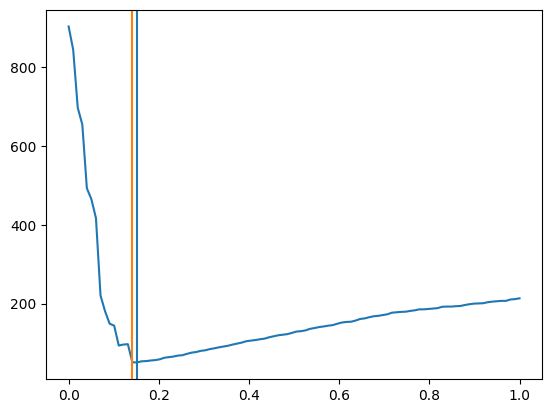

In [39]:
from tqdm.auto import tqdm

eps = 1e-14

cache_a = make_cache(a, b)
cache_b = make_cache(b, a)

lambdas = np.linspace(0, 1, 100)

rankings_a = []
rankings_b = []
rankings_combined = []
for lambda_ in tqdm(lambdas):
#     score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
#     rankings.append(np.argsort(-score).tolist().index(j))

    score_a = npmi_batch_popularity_weighted(mat, a, lambda_, cache=cache_a, eps=eps)
    score_b = npmi_batch_popularity_weighted(mat, b, lambda_, cache=cache_b, eps=eps)
    
    rankings_a.append(np.argsort(-score_a).tolist().index(b))
    rankings_b.append(np.argsort(-score_b).tolist().index(a))
    rankings_combined.append((rankings_a[-1] + rankings_b[-1])/2)

# min(np.diff(rankings))

import matplotlib.pyplot as plt

rankings = rankings_combined

plt.plot(lambdas, rankings);
plt.axvline(lambdas[np.argmin(rankings)]);
plt.axvline(.14, c="tab:orange");

In [32]:
lambdas[np.argmin(rankings)]

np.float64(0.15151515151515152)

In [33]:
min(rankings)

50.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
a_to_b_error_metric_npmi_pop_weighted(artist_mat, a, b, lambda_)

lambda_: 0.13408607326731756
error: 47.5


47.5

In [396]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
#     py = (py * o) + (.5 * (1 - o))
#     px = (px * o) + (.5 * (1 - o))
#     pxy = (pxy * o) + (.5**2 * (1 - o))
#     pxy = (pxy * o) + ((px * py) * (1 - o))

#     px = py = np.where(px > py, px, py)
    px = py = (px + py)/2
#     px = py = px + py

#     px = np.where(px > py, px, py)
#     px = (px + py)/2
#     px = px + py
    
#     py = np.where(px > py, px, py)
#     py = (px + py)/2
#     py = px + py

#     py = np.where(px < py, px, py)
    score = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)

    if call_again:
        return (metric(j, i, o, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [397]:
metric(a, b, .6)

98.5

In [267]:
metric(a, b, .11)

105.0

In [246]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Quiet Arrows (spotify:artist:7KRnRH8bRvoX4ebQwHw2EI)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'This, the Silent War (spotify:artist:3156bBfcG5gFSWrftU8gaR)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Josh Jenkins (spotify:artist:20nyUQUh2kYdqOauF3y3Pu)',
 'Choir Of Young Believers (spotify:artist:4aXPrNXYJLziXeH7Obkea7)',
 'Samaris (spotify:artist:1Xl5hsislt88ijOD3EZsOY)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Adurn (spotify:artist:4hDzPWJ7vNSD2wCEF49w8r)',
 'Joe Banfi (spotify:artist:5XuI2JDHF

In [37]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [33]:
top_k = 20

In [34]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, a, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)',
 'Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)',
 'Mikkel Øwre (spotify:artist:1kNHqkERzDBPrzdK9DogGQ)',
 'Pieces of Juno (spotify:artist:1k88AWvVVqKbz6C0kK624d)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'A-Laget (spotify:artist:2eJz0fbC9ZqBL3mGWPBvI5)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Carl Louis (spotify:artist:5LY4Rzduoz5b0qZdV3rHwK)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Morten Myklebust (spotify:artist:7zFc6IlzgDwyXoj

In [35]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, b, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)',
 'The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'Low Volts (spotify:artist:3PxUwSSsVaW0XyBiRJF2oS)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Panama (spotify:artist:3W9UldYu0xJcaOA